In [1]:
from netCDF4 import Dataset
import datetime
import warnings
import matplotlib
import pandas as pd
import os
import numpy as np
from scipy.signal import argrelextrema
import pickle
from scipy.stats import linregress
import warnings
import matplotlib.pyplot as plt
# import sys
# sys.path.append('/home/robbie/custom_modules/')
from ll_xy import lonlat_to_xy
import kuka_tools as kt
# You can find kuka_tools at https://github.com/robbiemallett/custom_modules/blob/master/kuka_tools.py

In [2]:
directory = '/home/robbie/Dropbox/kuka_slush/data/kuka/20231002'

freqs=['ku','ka']
listfiles = os.listdir(directory)
files = {'ku':sorted([f for f in listfiles if f'Ku-Scat' in f]),
         'ka':sorted([f for f in listfiles if f'Ka-Scat' in f])}

files

{'ku': ['kuka_stare_decon_Ku-Scat20231002-181013.nc',
  'kuka_stare_decon_Ku-Scat20231002-181513.nc'],
 'ka': ['kuka_stare_decon_Ka-Scat20231002-181204.nc',
  'kuka_stare_decon_Ka-Scat20231002-181704.nc']}

In [3]:
d = Dataset(f'{directory}/kuka_stare_decon_Ku-Scat20231002-181513.nc')

kuka_stare_decon_Ku-Scat20231002-181013.nc 646
kuka_stare_decon_Ku-Scat20231002-181513.nc 336
kuka_stare_decon_Ka-Scat20231002-181204.nc 1158
kuka_stare_decon_Ka-Scat20231002-181704.nc 1048


Text(0, 0.5, 'y distance (m)')

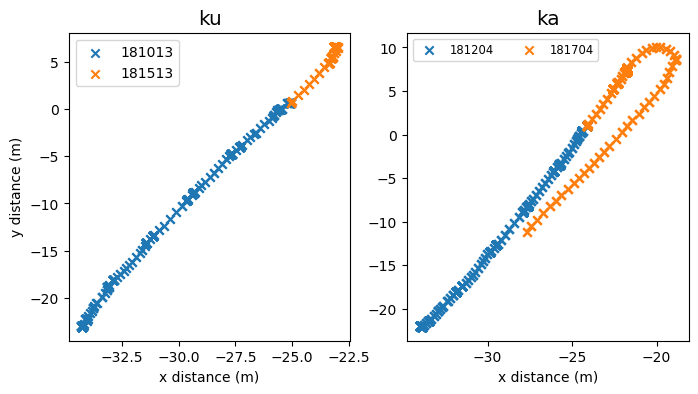

In [4]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4))

xy_dict = {}

for freq, ax in zip(freqs,[ax1,ax2]):
    
    ax.set_title(freq,fontsize='x-large')
    
    x,y=kt.plot_pos(files['ku'][0],directory,plot=False)
    

    x0 = -2300414.994491106; y0 = 923485.871699531

    xy_dict[freq]={}
    
    for f in files[freq]:

        x,y = kt.plot_pos(f,directory,x0=x0,y0=y0,ax=ax)
        
        print(f,len(x))

        xy_dict[freq][f] = (x,y)

ax1.legend()
ax2.legend(ncol=2,fontsize='small')
ax1.set_xlabel('x distance (m)')
ax2.set_xlabel('x distance (m)')
ax1.set_ylabel('y distance (m)')

In [5]:
# for freq in freqs:  
#     for f in files[freq]:
#         kt.plot_file(f,freq.lower(),directory,
#                          vlines=[])

In [6]:
nearfardict = {}

for freq in ['ku','ka']:
    
    file = files[freq][0]
    d = Dataset(f'{directory}/{file}')
    near=kt.get_range_index(1.3,d['range'])
    far=kt.get_range_index(3,d['range'])
    nearfardict[freq] = {'near':near,'far':far,'range':np.array(d['range'])[near:far]}

pickle.dump(nearfardict,open('nearfardict','wb'))

/tmp/ipykernel_23556/1100122652.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nearfardict[freq] = {'near':near,'far':far,'range':np.array(d['range'])[near:far]}


# Combine Files

In [13]:
d

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    title: KuKa combined echo and summary data
    file_processed_with: KuKaPy translated from ProSensing IDL code by Vishnu Nandan with additions by Rosemary Willatt, Thomas Newman and Robbie Mallett
    date_created: 20240131
    data_type: KuKaPy output
    current_calibration_loop_power: 0.0026216508837656155
    n_groups: 1048
    n_blocks_per_group: 1
    dimensions(sizes): sample(1048), range(4096), pol(4)
    variables(dimensions): |S1 polarisation(pol), float64 along_tilt(sample), float64 cross_tilt(sample), float64 start_time(sample), float64 lat(sample), float64 lon(sample), float64 range(range), float64 vv_power_decon0(range, sample), float64 hv_power_decon0(range, sample), float64 vh_power_decon0(range, sample), float64 hh_power_decon0(range, sample), float64 range_peak_signal_decon0(sample), float64 nrcs_decon0(pol, sample), float64 rho_hv_vec_decon0(sample), float64 phase_hv_deg_vec_decon0(sampl

In [15]:
with warnings.catch_warnings():
    
    warnings.simplefilter('ignore')
    
    data = {}
    
    for freq in ['ku','ka']:
    
        nrcs_list = []
        for foi in files[freq][0:2]:
    
            x,y=xy_dict[freq][foi]
    
            d = Dataset(f'{directory}/{foi}')

            print('lon',np.nanmin(d['lon']))
            print(np.nanmin(d['lat']))
            print('lon',np.nanmax(d['lon']))
            print(np.nanmax(d['lat']))
    
            time_offset_s=0
            times = np.array([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(x))+datetime.timedelta(seconds=int(time_offset_s)) for x in d['start_time']])
    
            mintime=0
            maxtime=100000
    
            nrcs = pd.DataFrame(kt.get_nrcs(d,freq.lower()))
    
            x_ = 0; y_ = 0
    
            along_track = np.sqrt((x-x_)**2 + (y-y_)**2)
            xdiff = np.diff(x)
            ydiff = np.diff(y)
            speed = np.sqrt(np.square(xdiff)+np.square(ydiff))
            speed=list(speed)+[0]
            nrcs['speed']=speed
            nrcs['along_track']=along_track
            nrcs['time']=np.array(d['start_time']).copy()
            nrcs['x']=x
            nrcs['y']=y
            nrcs['xtilt']=np.array(d['cross_tilt'])
            nrcs['atilt']=np.array(d['along_tilt'])
            nrcs = nrcs.iloc[mintime:maxtime]
    
            vv= np.array(d['vv_power_decon0'])[nearfardict[freq]['near']:nearfardict[freq]['far'],
                                               mintime:maxtime]
            
            hv= np.array(d['hv_power_decon0'])[nearfardict[freq]['near']:nearfardict[freq]['far'],
                                               mintime:maxtime]
            
            nrcs['vv'] = [vv[:,i] for i in range(vv.shape[1])]
            nrcs['hv'] = [hv[:,i] for i in range(hv.shape[1])]
            
            nrcs['code']=[str(i)+foi for i in nrcs.index]
    
            nrcs = nrcs[nrcs['corr']<0.99]
    
            nrcs_list.append( nrcs )
            
    
        data[freq] = pd.concat(nrcs_list)

lon -68.12813382428934
-67.56462937505617
lon -68.12754510473515
-67.56462244253439
lon -68.12754520668837
-67.56462636303755
lon -68.12740035998408
-67.56462209032803
lon -68.12810890388187
-67.56463469232826
lon -68.12752940456964
-67.56462734200935
lon -68.12782251252031
-67.56465551890481
lon -68.12729912980059
-67.56463031091106


# Set frequency here

(197, 13)
(197, 13)


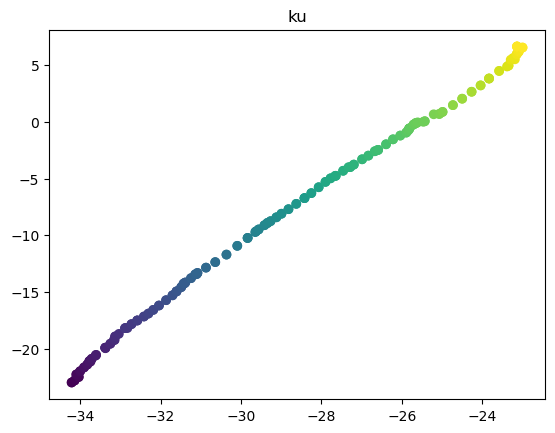

(461, 13)
(461, 13)


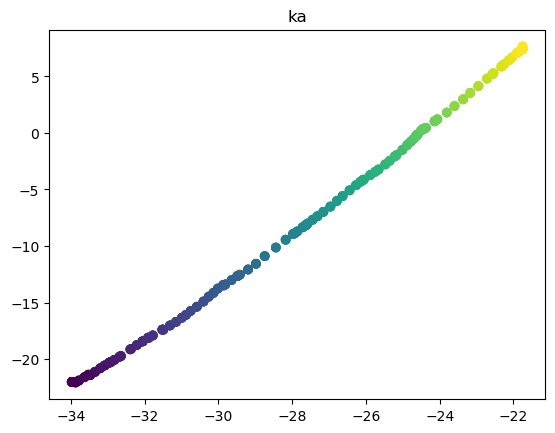

In [14]:
for freq in freqs:
    df = data[freq]
    print(df.shape)
    df=df.iloc[:461]

    data[freq]=df
    
    print(df.shape)
    
    x0=np.min(df['x'])
    y0=np.min(df['y'])
    df['along_track']=np.sqrt((df['x']-x0)**2+(df['y']-y0)**2)
    
    end=90000
    plt.scatter(df['x'][:end],df['y'][:end],c=df['along_track'][:end])
    plt.title(freq)
    plt.show()

pickle.dump(data,open('20206_10_02_wfms','wb'))